In [1]:
# Install required libraries.
!pip install sentence-transformers seaborn matplotlib scikit-learn

# Import libraries
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
sentences = [
## Cricket
   "The batman scored a century in the final match.",
   "The bowler delivered a fast yorker that broke the stumps.",
   "Fielder saved crucial runs near the boundary line.",
   "4. The cricket team celebrated their victory.",


## Cooking
   "The chef prepared a delicious pasta with fresh ingredients.",
   "Slow-cooking the meat at a low temperature ensures it stays tender.",
   "The soup was simmered slowly to enhance the flavor.",

## Cybersecurity
   "Cybersecurity experts monitor networks to prevent data breaches.",
   "Strong passwords help protect accounts from hackers.",
   "Encryption ensures that sensitive information remains secure.",
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

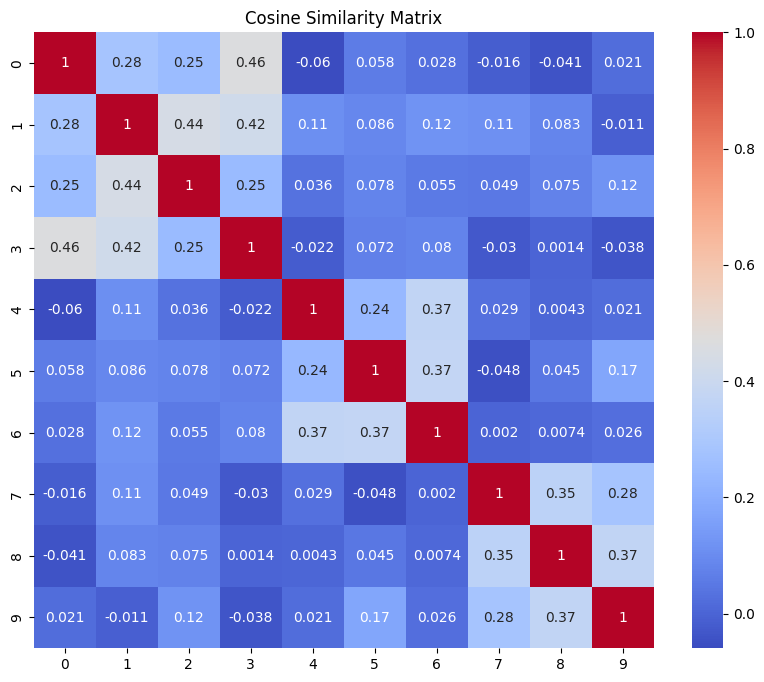

In [3]:
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embedding = model.encode(sentences)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(embedding)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title('Cosine Similarity Matrix')
plt.show()

In [4]:
query = "The bowler took three wickets in a over"

# Encode query
query_embedding = model.encode([query])

# Compute cosine similarity
similarities = cosine_similarity(query_embedding, embedding)[0]

# Get top 2 most similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 Most Similar Sentences:\n")

for idx in top_indices:
  print(sentences[idx])
  print("Similarity Score:", similarities[idx])
  print()

Query: The bowler took three wickets in a over

Top 2 Most Similar Sentences:

The bowler delivered a fast yorker that broke the stumps.
Similarity Score: 0.61142325

4. The cricket team celebrated their victory.
Similarity Score: 0.5429752

